In [12]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

In [13]:
import pandas as pd
from rdkit.Chem import PandasTools

In [14]:
AA="C:/Users/ganes/OneDrive/Desktop/AI/Drug/DNA/Valid_Smiles.xlsx"
df=pd.read_excel(AA)
df.head(5)


,Smiles
0,CN1CCN(CC1)c1cc2nc([NH]c2cc1)c1cc2nc([NH]c2cc1...
1,CN1CCN(CC1)c1cc2nc([NH]c2cc1)c1ccc2[NH]c(nc2c1...
2,O=C1NC(=O)C2(Cc3cc4c(onc4C4SN=NN4C)c(F)c3N3CC(...


In [15]:
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='Smiles', )
df.head(48)

,Smiles,ROMol
0,CN1CCN(CC1)c1cc2nc([NH]c2cc1)c1cc2nc([NH]c2cc1...,<rdkit.Chem.rdchem.Mol object at 0x00000196003...
1,CN1CCN(CC1)c1cc2nc([NH]c2cc1)c1ccc2[NH]c(nc2c1...,<rdkit.Chem.rdchem.Mol object at 0x00000196003...
2,O=C1NC(=O)C2(Cc3cc4c(onc4C4SN=NN4C)c(F)c3N3CC(...,<rdkit.Chem.rdchem.Mol object at 0x00000196003...


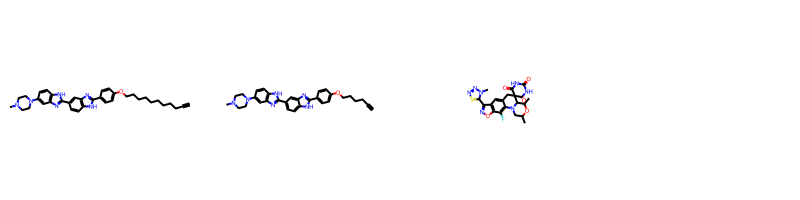

In [16]:
PandasTools.FrameToGridImage(df.head(20), molsPerRow=4)

In [17]:
radius = 3
nBits = 1024

DNA_New_Drug = [AllChem.GetMorganFingerprintAsBitVect(x, radius=radius, nBits=nBits) for x in df['ROMol']]


[23:31:40] DEPRECATION WARNING: please use MorganGenerator
[23:31:40] DEPRECATION WARNING: please use MorganGenerator
[23:31:40] DEPRECATION WARNING: please use MorganGenerator


In [18]:
len(DNA_New_Drug[0])

1024

In [19]:
DNA_name = [f'Bit_{i}' for i in range(nBits)]
DNA_bits = [list(l) for l in DNA_New_Drug]
df_DNA = pd.DataFrame(DNA_bits, index = df.Smiles, columns=DNA_name)
df_DNA.head(1)

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_1014,Bit_1015,Bit_1016,Bit_1017,Bit_1018,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023
Smiles,,,,,,,,,,,,,,,,,,,,,
CN1CCN(CC1)c1cc2nc([NH]c2cc1)c1cc2nc([NH]c2cc1)c1ccc(OCCCCCCCCCC#C)cc1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
file_name = 'VAN_String.xlsx'
df_DNA.to_excel(file_name)